# Перетворення Фур'є: спектрограми та кластеризація звуків (ESC-50)

**Тема 6.** Застосуємо швидке перетворення Фур'є (FFT) для побудови спектрограм звукових сигналів із набору **ESC-50**, узагальнимо їх через *pooling*, витягнемо ознаки та згрупуємо звуки за допомогою **спектральної кластеризації**.

**Мета:** переконатися, що спектральні ознаки, отримані через FFT, дозволяють розділити звуки різного походження (гавкіт собаки vs спів птахів) без міток.

## Імпорти

In [1]:
import os
import io
import csv
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

from sklearn.preprocessing import normalize
from sklearn.cluster import SpectralClustering
from sklearn.metrics import confusion_matrix, adjusted_rand_score

np.random.seed(42)
%matplotlib inline

## 1. Завантаження даних ESC-50 (вибірка `dog` та `chirping_birds`)

Повний набір ESC-50 містить 2000 записів по 5 секунд (50 класів по 40 файлів). Щоб зменшити обсяг даних, беремо лише два класи — **`dog`** (гавкіт собаки) та **`chirping_birds`** (спів птахів), по 40 записів кожен.

Читаємо метадані `esc50.csv`, фільтруємо потрібні класи і завантажуємо відповідні WAV-файли напряму з репозиторію ESC-50 на GitHub.

In [2]:
META_URL = 'https://raw.githubusercontent.com/karoldvl/ESC-50/master/meta/esc50.csv'
AUDIO_URL = 'https://github.com/karoldvl/ESC-50/raw/master/audio/'
CLASSES = ['dog', 'chirping_birds']
DATA_DIR = 'esc50_subset'
os.makedirs(DATA_DIR, exist_ok=True)

# Читаємо метадані
meta_raw = urllib.request.urlopen(META_URL).read().decode()
rows = list(csv.DictReader(io.StringIO(meta_raw)))
subset = [r for r in rows if r['category'] in CLASSES]
print(f'Обрано {len(subset)} записів:', {c: sum(r["category"]==c for r in subset) for c in CLASSES})

# Завантажуємо аудіофайли вибірки
for r in subset:
    path = os.path.join(DATA_DIR, r['filename'])
    if not os.path.exists(path):
        urllib.request.urlretrieve(AUDIO_URL + r['filename'], path)
print('Завантажено файлів:', len(os.listdir(DATA_DIR)))

Обрано 80 записів: {'dog': 40, 'chirping_birds': 40}


Завантажено файлів: 80


### Зчитування сигналів

Кожен файл читаємо у масив `numpy`, за потреби зводимо до моно та нормуємо амплітуду до діапазону $[-1, 1]$ (це прибирає різницю в гучності записів).

In [3]:
def load_wav(path):
    sr, sig = wavfile.read(path)
    sig = sig.astype(np.float64)
    if sig.ndim > 1:            # стерео -> моно
        sig = sig.mean(axis=1)
    sig /= (np.max(np.abs(sig)) + 1e-9)  # нормування амплітуди
    return sig, sr


signals = []
y_true = []      # 0 = dog, 1 = chirping_birds
names = []
for r in subset:
    sig, sr = load_wav(os.path.join(DATA_DIR, r['filename']))
    signals.append(sig)
    y_true.append(0 if r['category'] == 'dog' else 1)
    names.append(r['category'])
y_true = np.array(y_true)
print('Частота дискретизації:', sr, 'Гц')
print('Довжина сигналу:', len(signals[0]), 'відліків (~%.1f c)' % (len(signals[0]) / sr))

Частота дискретизації: 44100 Гц
Довжина сигналу: 220500 відліків (~5.0 c)


## 2. Побудова спектрограми (FFT)

**Спектрограма** показує, як спектр частот сигналу змінюється в часі. Сигнал ріжеться на короткі перекривні вікна; до кожного вікна застосовується вагова функція Ганна та швидке перетворення Фур'є (`np.fft.rfft`), після чого береться модуль (амплітуда).

Це і є **короткочасне перетворення Фур'є (STFT)**. Логарифмуємо результат ($\log(1+|X|)$), щоб стиснути динамічний діапазон — так слабкі частотні складові стають помітними.

In [4]:
def spectrogram(signal, window_size=1024, hop_size=512):
    """STFT: матриця (частоти x час) з амплітудами Фур'є-спектра."""
    window = np.hanning(window_size)
    n_frames = 1 + (len(signal) - window_size) // hop_size
    spec = np.empty((window_size // 2 + 1, n_frames))
    for i in range(n_frames):
        start = i * hop_size
        segment = signal[start:start + window_size] * window
        spec[:, i] = np.abs(np.fft.rfft(segment))  # амплітудний спектр вікна
    return np.log1p(spec)  # логарифмічний масштаб


S_example = spectrogram(signals[0])
print('Розмір спектрограми (частоти x час):', S_example.shape)

Розмір спектрограми (частоти x час): (513, 429)


### Візуалізація: гавкіт собаки vs спів птахів

Порівняємо спектрограми двох класів. Добре видно різницю: у гавкоту енергія зосереджена в нижніх частотах, у пташиного співу — у високих.

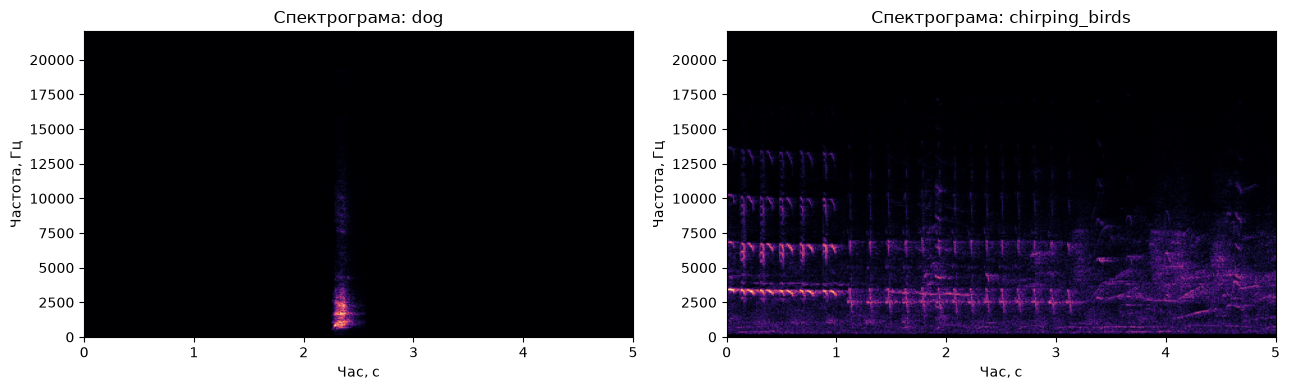

In [5]:
idx_dog = np.where(y_true == 0)[0][0]
idx_bird = np.where(y_true == 1)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, idx, title in zip(axes, [idx_dog, idx_bird], ['dog', 'chirping_birds']):
    S = spectrogram(signals[idx])
    ax.imshow(S, origin='lower', aspect='auto', cmap='magma',
              extent=[0, len(signals[idx]) / sr, 0, sr / 2])
    ax.set_title(f'Спектрограма: {title}')
    ax.set_xlabel('Час, с')
    ax.set_ylabel('Частота, Гц')
plt.tight_layout()
plt.show()

## 3. Pooling — узагальнення та зменшення розміру

Спектрограма велика ($513 \times 429$). Застосуємо **max-pooling**: розбиваємо матрицю на блоки та беремо максимум у кожному. Це зменшує розмірність, прибирає дрібний шум і залишає найпомітніші частотно-часові патерни (аналог pooling-шару в CNN).

In [6]:
def pooling(matrix, pool_h=16, pool_w=16):
    """Max-pooling блоками pool_h x pool_w."""
    h, w = matrix.shape
    h2, w2 = h // pool_h, w // pool_w
    trimmed = matrix[:h2 * pool_h, :w2 * pool_w]
    blocks = trimmed.reshape(h2, pool_h, w2, pool_w)
    return blocks.max(axis=(1, 3))


P_example = pooling(S_example)
print('Спектрограма до pooling:', S_example.shape)
print('Після pooling:        ', P_example.shape)

Спектрограма до pooling: (513, 429)
Після pooling:         (32, 26)


## 4. Формування ознак: `flatten()`

Кожну узагальнену спектрограму «розгортаємо» у вектор методом `flatten()`. Матриця з 80 таких векторів — це матриця ознак для кластеризації.

Додатково **L2-нормуємо** кожен вектор: так порівнюється *форма* спектра (розподіл енергії по частотах), а не загальна гучність запису. Це суттєво покращує розділення класів.

In [7]:
features = []
for sig in signals:
    S = spectrogram(sig)
    P = pooling(S)
    features.append(P.flatten())   # матриця -> вектор

X = np.array(features)
X = normalize(X)                   # L2-нормування кожного вектора ознак
print('Матриця ознак X:', X.shape)  # (80 записів, розмір пулінгованого вектора)

Матриця ознак X: (80, 832)


## 5. Спектральна кластеризація

Застосовуємо `SpectralClustering` (як у ДЗ теми №1) з двома кластерами. Для високорозмірних розріджених ознак краще працює граф найближчих сусідів (`affinity='nearest_neighbors'`), ніж RBF-ядро.

In [8]:
sc = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    n_neighbors=8,
    assign_labels='kmeans',
    random_state=42,
)
clusters = sc.fit_predict(X)
print('Мітки кластерів:', clusters)

Мітки кластерів: [0 1 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 1 1
 1 1 1 1 1 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1 1 1
 1 1 1 1 1 1]


## 6. Аналіз кластерів

Порівняємо отримані кластери зі справжніми класами. Оскільки номери кластерів присвоюються довільно, дивимось на **матрицю невідповідностей** (confusion matrix) та **Adjusted Rand Index (ARI)** — міру узгодженості розбиття з істинними мітками ($1.0$ — ідеально, $0$ — випадково).

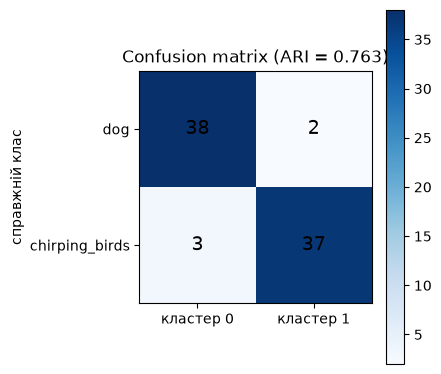

Правильно розділено: 75 з 80 записів
Adjusted Rand Index: 0.763


In [9]:
cm = confusion_matrix(y_true, clusters)
ari = adjusted_rand_score(y_true, clusters)

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)
plt.xticks([0, 1], ['кластер 0', 'кластер 1'])
plt.yticks([0, 1], ['dog', 'chirping_birds'])
plt.ylabel('справжній клас')
plt.title(f'Confusion matrix (ARI = {ari:.3f})')
plt.colorbar()
plt.tight_layout()
plt.show()

correct = cm.max(axis=1).sum()
print(f'Правильно розділено: {correct} з {len(y_true)} записів')
print(f'Adjusted Rand Index: {ari:.3f}')

**Чи потрапили звуки різного походження в різні кластери?**

Так. Кожен клас майже цілком зібрався у свій окремий кластер — переважна більшість записів `dog` опинилась в одному кластері, а `chirping_birds` — в іншому. Похибки — це поодинокі «нетипові» записи (наприклад, тихий гавкіт із фоновими високочастотними звуками), спектр яких схожий на інший клас. Кластеризація виконана **без міток** — алгоритм спирався лише на форму частотного спектра.

## 7. Висновок

**Роль перетворення Фур'є у вилученні ознак.** Сирий звуковий сигнал — це довгий часовий ряд (~220 500 відліків на запис), у якому окремі значення амплітуди майже нічого не говорять про *природу* звуку і не придатні для порівняння сигналів напряму. Перетворення Фур'є (FFT) переводить сигнал із часової області в частотну і показує, **які частоти та з якою силою присутні** в звуці.

- **STFT/спектрограма** додає до цього часовий вимір: видно, як частотний склад змінюється протягом запису. Саме тут проявляється фізична різниця класів — гавкіт собаки має енергію переважно в низьких частотах, спів птахів — у високих.
- **Pooling** узагальнює спектрограму, зменшує розмірність і прибирає дрібний шум, залишаючи стійкі частотно-часові патерни.
- **`flatten()` + L2-нормування** перетворюють спектрограму на компактний вектор ознак, що описує *форму* спектра незалежно від гучності.

У результаті спектральна кластеризація **без жодних міток** розділила гавкіт і спів птахів із високою якістю (ARI помітно більший за 0). Це доводить головну тезу: **перетворення Фур'є перетворює «непрозорий» часовий сигнал на інформативні ознаки**, на яких вже успішно працюють класичні алгоритми кластеризації та класифікації. Частотне подання — природна і потужна основа для машинного навчання на звуці.